# Imports

In [1]:
from model_builder import ModelBuilder
from model_utils import *
import random
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import colorsys
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from bokeh.plotting import figure, output_file, show
from bokeh.models import HoverTool, ColumnDataSource, ColorMapper
from bokeh.transform import linear_cmap
from bokeh.palettes import Viridis256
from itertools import cycle
plt.rcParams["font.family"] = "Times New Roman"
import warnings
warnings.filterwarnings("ignore")

In [2]:
with open("config.json", "rb") as json_file:
    config = json.load(json_file)
config

{'becker': {'filename': 'beckerestimation_output_conversation_level.csv',
  'cols_to_ignore': ['conversation_num',
   'mean_pre_discussion_error',
   'mean_post_discussion_error',
   'median_pre_discussion_error',
   'median_post_discussion_error',
   'median_pre_discussion_error_pct',
   'median_post_discussion_error_pct',
   'mean_pre_discussion_error_pct',
   'mean_post_discussion_error_pct',
   'reverse_mean_post_discussion_error_pct',
   'reverse_median_post_discussion_error_pct',
   'question',
   'chatrooms',
   'trial_indx']},
 'csop': {'filename': 'csop_output_conversation_level.csv',
  'cols_to_ignore': ['conversation_num',
   'batch_num',
   'round_num',
   'round_index',
   'task_index',
   'complexity',
   'type',
   'social_perceptiveness',
   'skill',
   'normalized_score',
   'score',
   'duration',
   'efficiency']},
 'csopII': {'filename': 'csopII_output_conversation_level.csv',
  'cols_to_ignore': ['conversation_num',
   'batch_num',
   'vis_img',
   'int_verb',
   '

# Jury

In [3]:
# Define the basic model
juries_model = ModelBuilder(dataset_names = ["juries"])
juries_model.select_target(target=["majority_pct"])
juries_model.define_model(model_type = 'rf')

# CSOP (blended)

In [4]:
csop_blended_model = ModelBuilder(dataset_names = ["csop", "csopII"])
csop_blended_model.select_target(target=["efficiency", "efficiency"])
csop_blended_model.define_model(model_type = 'rf')

# DAT

In [5]:
dat_model = ModelBuilder(dataset_names = ["dat"])
dat_model.select_target(target=["efficiency"])
dat_model.define_model(model_type = 'rf')

# Estimation

In [6]:
estimation_blended_model = ModelBuilder(dataset_names = ["gurcay", "becker"])
estimation_blended_model.select_target(target=["mean_post_discussion_error_pct", "mean_post_discussion_error_pct"])
estimation_blended_model.define_model(model_type = 'rf')

# Create a PCA plot of the conversation features, colored by task

In [7]:
juries_data = pd.read_csv('../output/jury_output_conversation_level.csv')
csop_data = pd.read_csv('../output/csop_output_conversation_level.csv')
csopII_data = pd.read_csv('../output/csopII_output_conversation_level.csv')
dat_data = pd.read_csv('../output/dat_output_conversation_level.csv')
becker_data = pd.read_csv('../output/beckerestimation_output_conversation_level.csv')
gurcay_data = pd.read_csv('../output/gurcay2015estimation_output_conversation_level.csv')

In [8]:
juries_data, csop_data, csopII_data, dat_data, becker_data, gurcay_data = drop_non_common_columns([juries_data, csop_data, csopII_data, dat_data, becker_data, gurcay_data])

csop_blended_data = pd.concat([csop_data,csopII_data], axis=0)
estimation_blended_data = pd.concat([becker_data,gurcay_data], axis=0)

In [9]:
juries_data, csop_blended_data, dat_data, estimation_blended_data = get_numeric_cols([juries_data, csop_blended_data, dat_data, estimation_blended_data])

In [10]:
juries_data, csop_blended_data, csop_data, csopII_data, dat_data, estimation_blended_data, becker_data, gurcay_data = get_convs_with_min_value([juries_data, csop_blended_data, csop_data, csopII_data, dat_data, estimation_blended_data, becker_data, gurcay_data], "sum_num_messages", 10)

# PCA of Datasets

In [11]:
labels = ["Mock Jury", "Room Assignment Task", "Divergent Association Task", "Estimation"]
dataset_labels = ["Mock Jury", "CSOP", "CSOPII", "DAT", "Estimation (Becker)", "Estimation (Gurcay)"]

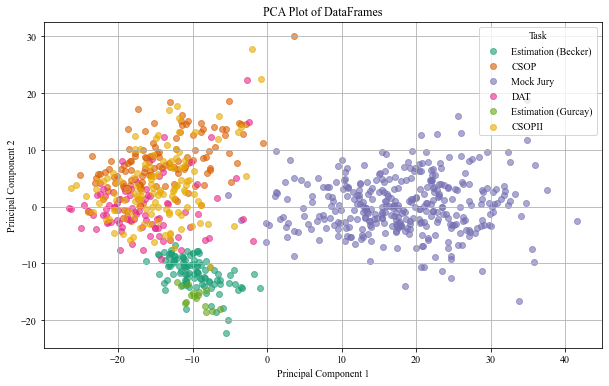

In [12]:
pca_results = plot_pca_of_dataframes(juries_data, csop_data, csopII_data, dat_data, becker_data, gurcay_data, labels=dataset_labels)

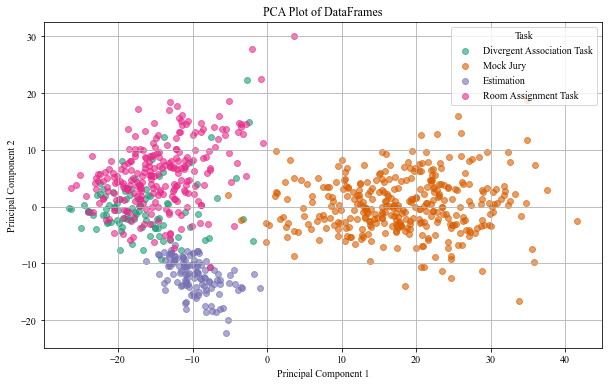

In [13]:
pca_results = plot_pca_of_dataframes(juries_data, csop_blended_data, dat_data, estimation_blended_data, labels=labels)

In [14]:
pca_results.explained_variance_ratio_

array([0.28305965, 0.05467009])

In [15]:
examine_top_n_components(pca_results, n=10)

Top 5 Features for PC1:
                                     Feature       PC1       PC2   PC1_abs  \
167               average_user_avg_num_chars  0.055279 -0.003081  0.055279   
272  average_user_avg_nltk_english_stopwords  0.055277  0.000367  0.055277   
598               average_user_avg_num_words  0.055266 -0.001289  0.055266   
860           average_nltk_english_stopwords  0.055121  0.001122  0.055121   
209                        average_num_chars  0.055113 -0.002596  0.055113   
294                        average_num_words  0.055079 -0.000560  0.055079   
73                average_user_sum_num_chars  0.054876  0.034931  0.054876   
588  average_user_sum_nltk_english_stopwords  0.054757  0.034861  0.054757   
334          average_user_avg_cognitive_mech  0.054608 -0.001255  0.054608   
804                   average_user_avg_verbs  0.054550  0.000480  0.054550   

      PC2_abs  
167  0.003081  
272  0.000367  
598  0.001289  
860  0.001122  
209  0.002596  
294  0.000560  
73   

,Feature,PC1,PC2,PC1_abs,PC2_abs
0,max_user_avg_hedge_words,0.013460,-0.070812,0.013460,0.070812
1,max_first_person_singular,0.035561,-0.032798,0.035561,0.032798
2,min_user_sum_health,-0.001575,0.009869,0.001575,0.009869
3,average_preposition,0.052142,0.000324,0.052142,0.000324
4,stdev_user_avg_past_tense,0.031645,-0.047407,0.031645,0.047407
...,...,...,...,...,...
1034,min_user_sum_hashedge,0.030869,0.039711,0.030869,0.039711
1035,average_user_avg_positive_affect,0.023007,0.035705,0.023007,0.035705
1036,min_user_sum_sadness,-0.001565,0.015506,0.001565,0.015506
1037,max_hashedge,0.016861,-0.014201,0.016861,0.014201


# PCA of Features

In [ ]:
#### TODO -- turn this into a function that is callable!

all_data = pd.concat([juries_data, csop_blended_data, dat_data, estimation_blended_data], join = 'inner', ignore_index = True)

In [ ]:
# Normalize WITHIN TASK
columns_to_normalize = [col for col in all_data.columns if col != 'task_name']

# Group by 'task_name' and normalize the columns within each group
normalized_df = all_data.copy()  # Make a copy to avoid modifying the original DataFrame
# normalize without the group
normalized_df[columns_to_normalize] = normalized_df[columns_to_normalize].transform(lambda x: (x - x.mean()) / x.std())


In [ ]:
# Drop NA columns
nan_cols, nan_rows = check_na_rows_cols(normalized_df)
normalized_df = normalized_df.drop(nan_cols, axis = 1)

In [ ]:
normalized_data_transposed = normalized_df.drop(["task_name"], axis=1).T

In [ ]:
# Assigning Clusters
# Assuming you have a DataFrame 'normalized_data_transposed' with PCA results

# Convert the DataFrame to a NumPy array
data = normalized_data_transposed #.drop('index', axis=1).values  # Assuming 'index' is the feature names column

# Define a range of cluster numbers to test
n_components_range = range(1, 11)
bic_scores = []
aic_scores = []

# Fit GMM models with different numbers of components
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(data)
    bic_scores.append(gmm.bic(data))
    aic_scores.append(gmm.aic(data))

# Plot BIC and AIC scores to find the optimal number of clusters
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(n_components_range, bic_scores, marker='o')
plt.title('BIC Score')
plt.xlabel('Number of Clusters')
plt.ylabel('BIC Score')

plt.subplot(1, 2, 2)
plt.plot(n_components_range, aic_scores, marker='o')
plt.title('AIC Score')
plt.xlabel('Number of Clusters')
plt.ylabel('AIC Score')

plt.tight_layout()
plt.show()

# Choose the optimal number of clusters based on BIC or AIC (lower is better)
optimal_n_components_bic = n_components_range[np.argmin(bic_scores)]
optimal_n_components_aic = n_components_range[np.argmin(aic_scores)]

print(f"Optimal number of clusters based on BIC: {optimal_n_components_bic}")
print(f"Optimal number of clusters based on AIC: {optimal_n_components_aic}")


In [ ]:
# Fit the GMM with the optimal number of components
optimal_gmm = GaussianMixture(n_components=optimal_n_components_aic, random_state=42)
optimal_gmm.fit(data)

# Assign cluster labels to the data
cluster_labels = optimal_gmm.predict(data)

In [ ]:
# Perform PCA for dimensionality reduction (2 components for 2D)
pca = PCA(n_components=2)
# Fit and transform your data
pca_data_transposed = pca.fit_transform(normalized_data_transposed)

# Create a new DataFrame with the PC scores and row names
pca_df = pd.DataFrame(data=pca_data_transposed, columns=["PC1", "PC2"], index=normalized_data_transposed.index)
pca_df["cluster"] = cluster_labels

In [ ]:
pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1]

In [ ]:
pca_df